# Base pseudo-code

In [35]:
import torch
from torch import nn, optim

def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi):
    model_t = f_theta_0
    theta_0 = [param.clone().detach() for param in f_theta_0.parameters()]
    mu = [torch.zeros_like(param, requires_grad=True) for param in theta_0]
    criterion = nn.KLDivLoss()
    optimizer = optim.LBFGS(mu, lr=eta_mu)

    for _ in range(T):
        with torch.no_grad():
            for param, theta, m in zip(model_t.parameters(), theta_0, mu):
                param.copy_((theta - xi * m).detach())

        upsilon = model_t(D_f)
        loss = criterion(upsilon, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu)

        loss.backward()
        optimizer.step()

    return model_t



# Code

In [110]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import torch.nn.functional as F
from torch.nn.utils.stateless import functional_call
import copy
import random
import matplotlib.pyplot as plt


In [93]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


In [104]:
class FullyConnectedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [105]:
def train_model(model, train_loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [111]:
def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer):
    model_t = copy.deepcopy(f_theta_0)
    theta_0 = {name: param.clone().detach() for name, param in model_t.named_parameters()}
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')

    if optimizer == 'SGD':
        optimizer = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        optimizer = optim.LBFGS(list(mu.values()), lr=eta_mu)

    loss_history = []  # List to store the loss values

    def closure():
        optimizer.zero_grad()
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        upsilon = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(upsilon, dim=1)
        loss = criterion(log_probs, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        loss_history.append(loss.item())  # Store the loss value for each iteration
        print(f"Loss: {loss.item()}")
        return loss

    # Optimization loop
    for _ in range(T):
        optimizer.step(closure)

    # After optimization, update the model parameters
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
        param.data.copy_(final_params[name])
    
    print("Fin de la procédure Forsaken.")
    
    # Plot the loss over iterations
    plt.plot(loss_history)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss during Forsaken Optimization')
    plt.show()

    return model_t


In [102]:
def forget_set(train_dataset):
    forget_indices = random.sample(range(len(train_dataset)), 100)
    D_f = Subset(train_dataset, forget_indices)
    print(f"Nombre de points dans D_f à forget : {len(D_f)}")
    forget_loader = DataLoader(D_f, batch_size=64, shuffle=False)
    return forget_loader, D_f


In [107]:
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total

# Execution

In [109]:
model = FullyConnectedNN()
train_model(model,  train_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7937
Epoch 2/5, Loss: 0.3051
Epoch 3/5, Loss: 0.2471
Epoch 4/5, Loss: 0.2101
Epoch 5/5, Loss: 0.1819


Nombre de points dans D_f à forget : 100
Loss: 6.563881874084473
Loss: 6.562081336975098
Loss: 4.595906734466553
Loss: 4.056928634643555
Loss: 3.454373598098755
Loss: 2.722316265106201
Loss: 2.044950485229492
Loss: 1.5543112754821777
Loss: 1.1498459577560425
Loss: 0.9126613140106201
Loss: 0.721331000328064
Loss: 0.5693694949150085
Loss: 0.4511438310146332
Loss: 0.37089431285858154
Loss: 0.31018921732902527
Loss: 0.257051944732666
Loss: 0.21389225125312805
Loss: 0.17988090217113495
Loss: 0.1517925262451172
Loss: 0.12750840187072754
Loss: 0.10822869837284088
Loss: 0.09222240746021271
Loss: 0.07660705596208572
Loss: 0.06512360274791718
Loss: 0.05395705997943878
Loss: 0.04581261798739433
Loss: 0.03922788426280022
Loss: 0.03261242061853409
Loss: 0.028508109971880913
Loss: 0.024481631815433502
Loss: 0.020845215767621994
Loss: 0.017825298011302948
Loss: 0.015298532322049141
Loss: 0.013410474173724651
Loss: 0.011703655123710632
Loss: 0.009834932163357735
Loss: 0.008523477241396904
Loss: 0.0075

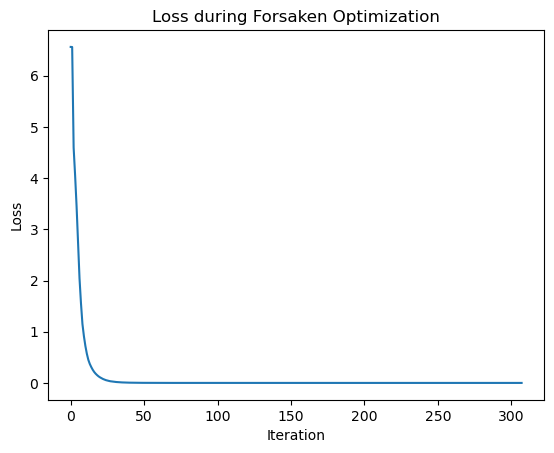

In [ ]:
forget_loader, D_f = forget_set(train_dataset)
images_forget, labels_forget = next(iter(forget_loader))

P = torch.full((images_forget.size(0), 10), 1/10)

T = 100
lambda_ = 0.1
omega = 1.0
eta_mu = 0.1
xi = 0.5

model_forsaken = forsaken(
    f_theta_0=model,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=images_forget,
    eta_mu=eta_mu,
    xi=xi,
    optimizer = 'LBFGS'
)


In [ ]:

accuracy_forget = evaluate_model(model_forsaken, forget_loader)
print(f"Accuracy sur D_f après Forsaken : {accuracy_forget:.2f}%")

accuracy_base = evaluate_model(model, forget_loader)
print(f"Accuracy sur D_f sans Forsaken : {accuracy_base:.2f}%")

accuracy_forget_test = evaluate_model(model_forsaken, test_loader)
print(f"Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

accuracy_base_test = evaluate_model(model, test_loader)
print(f"Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")


Accuracy sur D_f après Forsaken : 29.00%
Accuracy sur D_f sans Forsaken : 99.00%
Accuracy sur base de test après Forsaken : 95.08%
Accuracy sur base de test sans Forsaken : 95.08%
